# Credit Card Default Prediction

## Project Goal
The goal of this project is to predict whether a credit card client will default on payment next month using demographic, billing, and repayment history variables.

## Why this matters
Default prediction is an important classification problem in financial risk analysis. A well performing model can help identify higher risk clients and support better lending decisions.

## Project workflow
This notebook covers:
- Data Loading and Cleaning
- Exploratory Data Analysis (EDA)
- Preprocessing and Feature Engineering
- Model Training and Comparison
- Final Evaluation and Interpretation

## Reference and Data Intro
The Default of Credit Card Clients dataset contains information on 30,000 credit card clients from a Taiwan-based bank. It includes demographic variables, credit limit, repayment status, bill statement amounts, and previous payment amounts. The target variable is whether the client defaults on payment in the following month, making it a binary classification problem commonly used in credit risk modeling.


**Citation:** Yeh, I. (2009). *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.


<hr>

<!-- BEGIN QUESTION -->

## Imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Model selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
)

# Baseline model
from sklearn.dummy import DummyClassifier

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Feature selection and interpretation
from sklearn.feature_selection import RFECV
from sklearn.inspection import permutation_importance
from sklearn.metrics import RocCurveDisplay

# Evaluation metrics
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)


In [ ]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (30000, 25)

Columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


In [11]:
df.isnull().sum().sort_values(ascending=False).head(10)

ID           0
BILL_AMT2    0
PAY_AMT6     0
PAY_AMT5     0
PAY_AMT4     0
PAY_AMT3     0
PAY_AMT2     0
PAY_AMT1     0
BILL_AMT6    0
BILL_AMT5    0
dtype: int64

>The dataset contains 30,000 observations and 25 columns. Initial inspection suggests that the dataset is structured and ready for preprocessing, with no major missing-value issues to address.

<hr>

## 1. Target Variable

In [12]:
target_col = "default.payment.next.month"
X = df.drop(columns=[target_col])
y = df[target_col]

print("Target column:", target_col)
print("Number of features:", X.shape[1])
print("\nClass distribution:")
print(y.value_counts())

print("\nClass proportion:")
print(y.value_counts(normalize=True).round(4))

Target column: default.payment.next.month
Number of features: 24

Class distribution:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Class proportion:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


<hr>

## 2. Data Splitting
- To evaluate model performance fairly, the dataset was split into training and test sets before preprocessing and model fitting. Stratified splitting was used to preserve the class distribution in both sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).round(4))

X_train shape: (24000, 24)
X_test shape: (6000, 24)
y_train distribution:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

y_test distribution:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


>The dataset was split into 80% training data and 20% test data. Stratification ensured that the target class proportions remained similar across both sets, which is important given the class imbalance in the response variable.

<hr>

## 3. Exploratory Data Analysis


- This section explores a few key variables to better understand the data and identify patterns related to default risk. The focus is on variables that are likely to be important for later classification modeling.

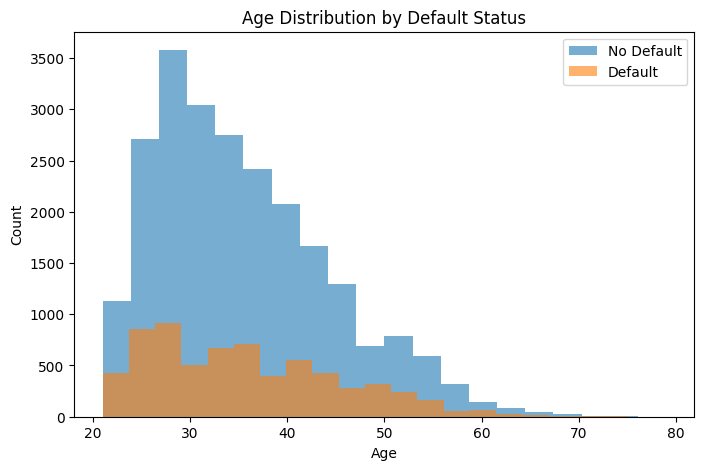

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df[df[target_col] == 0]["AGE"], bins=20, alpha=0.6, label="No Default")
plt.hist(df[df[target_col] == 1]["AGE"], bins=20, alpha=0.6, label="Default")

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution by Default Status")
plt.legend()
plt.show()

#### Figure 3.1
>The age distributions of the two groups overlap substantially, suggesting that age alone is unlikely to separate defaulters from non-defaulters. However, it may still contribute useful information when combined with other predictors.

/var/folders/pp/9qnt5sfs29b84h1tbb676c7w0000gn/T/ipykernel_10527/2208023044.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


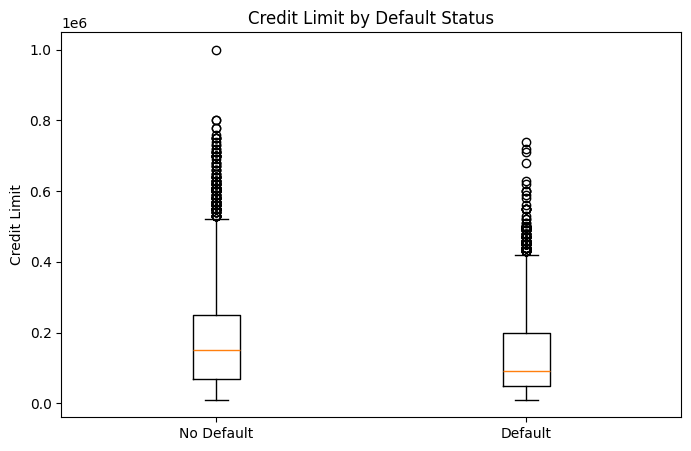

In [17]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [df[df[target_col] == 0]["LIMIT_BAL"], df[df[target_col] == 1]["LIMIT_BAL"]],
    labels=["No Default", "Default"]
)

plt.ylabel("Credit Limit")
plt.title("Credit Limit by Default Status")
plt.show()

#### Figure 3.2
>Clients who defaulted appear to have a different distribution of credit limits compared with non-defaulters. Although there is considerable overlap, credit limit may still be a relevant predictor of default behavior.

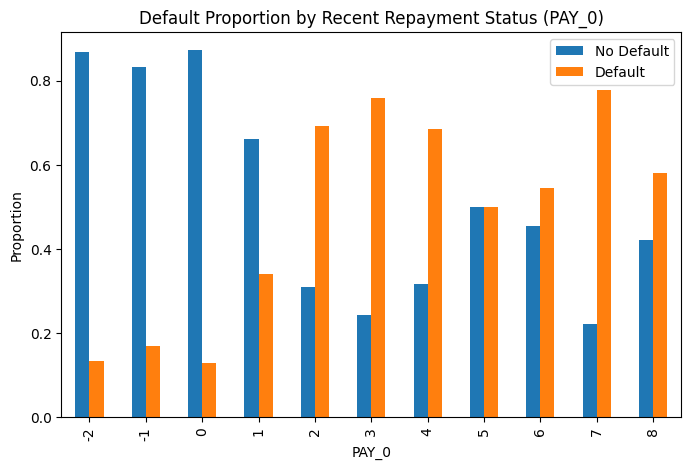

In [18]:
pay0_default = pd.crosstab(df["PAY_0"], df[target_col], normalize="index")

pay0_default.plot(kind="bar", figsize=(8, 5))

plt.xlabel("PAY_0")
plt.ylabel("Proportion")
plt.title("Default Proportion by Recent Repayment Status (PAY_0)")
plt.legend(["No Default", "Default"])
plt.show()

#### Figure 3.3
>Recent repayment status appears strongly related to default risk. Clients with worse repayment status in the most recent month tend to have a higher proportion of default, suggesting that repayment history is likely one of the most important predictors in this dataset.

### Personal Conclusion
>Overall, the exploratory analysis suggests that repayment related variables are likely to be more informative for default prediction than simple demographic variables alone. Credit limit and age may still provide useful supporting information, but recent repayment behavior appears especially important.

<hr>

## 4. Feature engineering

- This section prepares the feature set for modeling by separating the response variable from the predictors and identifying which variables should be treated as categorical or numeric. This helps structure the later preprocessing and modeling workflow more clearly.

In [19]:
target_col = "default.payment.next.month"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Target column:", target_col)
print("Number of predictors:", X.shape[1])

Target column: default.payment.next.month
Number of predictors: 24


In [20]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Number of numeric features:", len(numeric_features))

Categorical features: ['SEX', 'EDUCATION', 'MARRIAGE']
Number of numeric features: 21


In [21]:
print("Numeric features:")
print(numeric_features)

Numeric features:
['ID', 'LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


### Section Summary
> At this stage, the main feature engineering step is variable organization rather than heavy manual feature creation. Since the dataset already contains detailed billing, payment, and repayment variables, which preserves their original structure is a reasonable starting point for classification modeling. 

<hr>

## 5. Preprocessing and transformations
- Before model training, the predictors need to be transformed in a consistent and reproducible way. Numeric variables are imputed and scaled, while categorical variables are imputed and one-hot encoded. A column transformer is used so that these steps can be applied within a unified modeling pipeline.

In [22]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [23]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [24]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Section Summary
> <h7>Numeric and categorical variables require different preprocessing steps, so they are handled separately and then combined using a `ColumnTransformer`. This setup improves the consistency of the workflow and helps prevent data leakage by ensuring that transformations are applied within the modeling pipeline rather than on the full dataset in advance.</h7>

<hr>

## 6. Baseline model
   
- Before training more advanced classification models, a baseline model is used to establish a simple performance benchmark. Because the response variable is imbalanced, a dummy classifier provides a useful reference point for judging whether later models offer meaningful improvement.


In [25]:
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_baseline = baseline_pipeline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline Precision:", precision_score(y_test, y_pred_baseline, zero_division=0))
print("Baseline Recall:", recall_score(y_test, y_pred_baseline, zero_division=0))
print("Baseline F1 Score:", f1_score(y_test, y_pred_baseline, zero_division=0))

Baseline Accuracy: 0.7788333333333334
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1 Score: 0.0


### Section Summary
> The baseline model predicts only the majority class and serves as a minimum benchmark for performance. 

>Since the dataset is imbalanced, this model may achieve moderate accuracy while performing poorly on the minority class, which highlights why additional metrics beyond accuracy are needed.

<hr>

## 7. Linear models 

- Logistic regression is used as the main linear model in this project because it is a standard and interpretable method for binary classification. It provides a useful benchmark beyond the baseline model and helps evaluate whether a linear decision boundary can capture meaningful patterns in the data.

In [26]:
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)
y_prob_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Logistic Regression Precision:", precision_score(y_test, y_pred_logreg, zero_division=0))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_logreg, zero_division=0))
print("Logistic Regression F1 Score:", f1_score(y_test, y_pred_logreg, zero_division=0))
print("Logistic Regression ROC AUC:", roc_auc_score(y_test, y_prob_logreg))

Logistic Regression Accuracy: 0.8103333333333333
Logistic Regression Precision: 0.7266187050359713
Logistic Regression Recall: 0.22833458929917105
Logistic Regression F1 Score: 0.3474770642201835
Logistic Regression ROC AUC: 0.7273870916814207


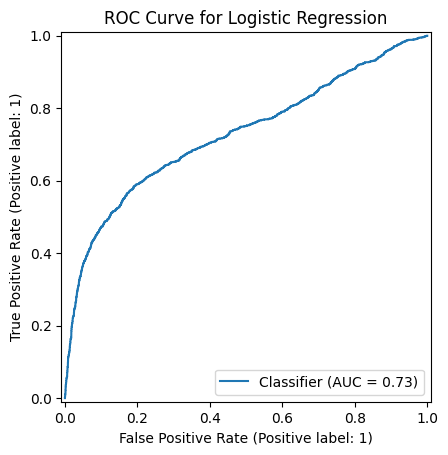

In [30]:
RocCurveDisplay.from_predictions(y_test, y_prob_logreg)
plt.title("ROC Curve for Logistic Regression")
plt.show()

### Section Summary

I trained a logistic regression model as my main linear classifier for this project and found that it provided a meaningful improvement over a simple baseline. On the test set, the model achieved an accuracy of about 0.810, a precision of about 0.727, a recall of about 0.228, an F1-score of about 0.347, and a ROC-AUC of about 0.724.

I observed that the model performed reasonably well in distinguishing between the two classes overall, as reflected by the ROC-AUC, but its recall on the default class remained relatively low. 

This suggests that while logistic regression offers a solid and interpretable benchmark for the problem, it may still miss a substantial number of true default cases under the default classification threshold.

<hr>

## 8. Different models

    
- To compare the linear benchmark with more flexible classification methods, I trained several additional models: a decision tree, k-nearest neighbors, and a random forest. These models allow me to examine whether non-linear approaches can capture patterns in the data more effectively than logistic regression.


### 8.1 Decistion Tree

In [31]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=123))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Decision Tree Recall:", recall_score(y_test, y_pred_dt, zero_division=0))
print("Decision Tree F1 Score:", f1_score(y_test, y_pred_dt, zero_division=0))
print("Decision Tree ROC AUC:", roc_auc_score(y_test, y_prob_dt))

Decision Tree Accuracy: 0.7113333333333334
Decision Tree Precision: 0.3628977657413676
Decision Tree Recall: 0.40391861341371516
Decision Tree F1 Score: 0.38231098430813126
Decision Tree ROC AUC: 0.6012745217721261


### 8.2 KNN

In [32]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Precision:", precision_score(y_test, y_pred_knn, zero_division=0))
print("KNN Recall:", recall_score(y_test, y_pred_knn, zero_division=0))
print("KNN F1 Score:", f1_score(y_test, y_pred_knn, zero_division=0))
print("KNN ROC AUC:", roc_auc_score(y_test, y_prob_knn))

KNN Accuracy: 0.7915
KNN Precision: 0.5452380952380952
KNN Recall: 0.34513941220798794
KNN F1 Score: 0.42270419935394554
KNN ROC AUC: 0.7043961438274131


### 8.3 Random Forest

In [33]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("Random Forest F1 Score:", f1_score(y_test, y_pred_rf, zero_division=0))
print("Random Forest ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Accuracy: 0.8195
Random Forest Precision: 0.6662125340599455
Random Forest Recall: 0.36850037678975134
Random Forest F1 Score: 0.4745269286754003
Random Forest ROC AUC: 0.7647291895222615


### 8.4 Comparison Table

In [34]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "KNN", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_knn, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_knn, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logreg, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_knn, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_logreg),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.810333,0.726619,0.228335,0.347477,0.727387
1,Decision Tree,0.711333,0.362898,0.403919,0.382311,0.601275
2,KNN,0.791500,0.545238,0.345139,0.422704,0.704396
3,Random Forest,0.819500,0.666213,0.368500,0.474527,0.764729


### Section Summary

I compared logistic regression with three additional models: a decision tree, k-nearest neighbors, and a random forest. 

Among these models, **the random forest achieved the strongest overall performance**, with the highest accuracy (0.8195), F1-score (0.4745), and ROC-AUC (0.7647), while also improving recall compared with logistic regression.

I observed that logistic regression had the highest precision (0.7266), but its recall was relatively low (0.2283), meaning that it missed many true default cases. 

In contrast, the random forest provided a better balance across evaluation metrics, especially for recall, F1-score, and ROC-AUC, which makes it the most effective model in this comparison. 

Overall, these results suggest that a more flexible nonlinear model can capture default patterns more effectively than a simple linear model.

<hr>

## 9. Feature selection 

    
- To better understand which predictors contribute most to the classification task, I applied recursive feature elimination with cross-validation (RFECV) using logistic regression as the estimator. This approach helps identify a smaller subset of useful features while balancing predictive performance and model simplicity.


In [35]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

Number of transformed features: 34


In [36]:
rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000),
    step=1,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rfecv.fit(X_train_processed, y_train)

print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 24


In [37]:
selected_features = feature_names[rfecv.support_]

print("Selected features:")
for feature in selected_features:
    print(feature)

Selected features:
num__LIMIT_BAL
num__PAY_0
num__PAY_2
num__PAY_3
num__PAY_5
num__BILL_AMT1
num__BILL_AMT2
num__BILL_AMT3
num__BILL_AMT4
num__PAY_AMT1
num__PAY_AMT2
num__PAY_AMT3
num__PAY_AMT4
cat__SEX_1
cat__SEX_2
cat__EDUCATION_0
cat__EDUCATION_1
cat__EDUCATION_2
cat__EDUCATION_3
cat__EDUCATION_4
cat__EDUCATION_5
cat__EDUCATION_6
cat__MARRIAGE_0
cat__MARRIAGE_1


In [38]:
X_train_selected = rfecv.transform(X_train_processed)
X_test_selected = rfecv.transform(X_test_processed)

logreg_selected = LogisticRegression(max_iter=1000)
logreg_selected.fit(X_train_selected, y_train)

y_pred_selected = logreg_selected.predict(X_test_selected)
y_prob_selected = logreg_selected.predict_proba(X_test_selected)[:, 1]

print("Selected-Feature Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_selected))
print("Selected-Feature Logistic Regression Precision:", precision_score(y_test, y_pred_selected, zero_division=0))
print("Selected-Feature Logistic Regression Recall:", recall_score(y_test, y_pred_selected, zero_division=0))
print("Selected-Feature Logistic Regression F1 Score:", f1_score(y_test, y_pred_selected, zero_division=0))
print("Selected-Feature Logistic Regression ROC AUC:", roc_auc_score(y_test, y_prob_selected))

Selected-Feature Logistic Regression Accuracy: 0.8106666666666666
Selected-Feature Logistic Regression Precision: 0.7334963325183375
Selected-Feature Logistic Regression Recall: 0.22607385079125847
Selected-Feature Logistic Regression F1 Score: 0.3456221198156682
Selected-Feature Logistic Regression ROC AUC: 0.7276189064759943


### Section Summary

I used RFECV with logistic regression to identify a smaller subset of features that retained most of the predictive information in the dataset. The selected features were mainly related to repayment status, bill amounts, payment amounts, and several encoded demographic variables, which suggests that both financial behavior and some client characteristics contribute to default prediction.

After fitting logistic regression on the selected features, the model achieved an accuracy of about 0.811, a precision of about 0.733, a recall of about 0.226, an F1-score of about 0.345, and a ROC-AUC of about 0.728. Compared with the full-feature logistic regression model, the performance remained very similar, indicating that feature selection was able to simplify the model without materially changing predictive performance. Overall, this result suggests that a reduced set of carefully selected predictors can preserve most of the useful signal in the data.

<hr>

## 10. Hyperparameter optimization

- After comparing several baseline and non-linear models, I tuned the most promising models to see whether better hyperparameter settings could improve predictive performance. 

- I focused on ROC-AUC as the main selection metric because this is an imbalanced binary classification problem. 
</div>

In [40]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_q10 = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

### 10.1 Logistic Regression Tuning

In [41]:
logreg_tune_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

logreg_tune_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

logreg_search = GridSearchCV(
    estimator=logreg_tune_pipe,
    param_grid=logreg_tune_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv_q10,
    n_jobs=-1,
    return_train_score=True
)

logreg_search.fit(X_train, y_train)

print("Logistic Regression best params:", logreg_search.best_params_)
print("Logistic Regression best CV ROC-AUC:", round(logreg_search.best_score_, 4))

Logistic Regression best params: {'model__C': 10, 'model__class_weight': 'balanced'}
Logistic Regression best CV ROC-AUC: 0.7247


### 10.2 KNN Tuning

In [42]:
knn_tune_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_tune_grid = {
    "model__n_neighbors": [10, 15, 25],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_search = GridSearchCV(
    estimator=knn_tune_pipe,
    param_grid=knn_tune_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv_q10,
    n_jobs=-1,
    return_train_score=True
)

knn_search.fit(X_train, y_train)

print("KNN best params:", knn_search.best_params_)
print("KNN best CV ROC-AUC:", round(knn_search.best_score_, 4))

KNN best params: {'model__n_neighbors': 25, 'model__p': 2, 'model__weights': 'uniform'}
KNN best CV ROC-AUC: 0.7424


### 10.3 Random Forest Tuning

In [43]:
rf_tune_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123, n_jobs=-1))
])

rf_tune_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_tune_pipe,
    param_distributions=rf_tune_grid,
    n_iter=12,
    scoring=scoring,
    refit="roc_auc",
    cv=cv_q10,
    random_state=123,
    n_jobs=-1,
    return_train_score=True
)

rf_search.fit(X_train, y_train)

print("Random Forest best params:", rf_search.best_params_)
print("Random Forest best CV ROC-AUC:", round(rf_search.best_score_, 4))

Random Forest best params: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 10, 'model__class_weight': None}
Random Forest best CV ROC-AUC: 0.7787


### 10.4 Results Wrapped Up

In [44]:
def summarize_search(search_obj, model_name):
    results = pd.DataFrame(search_obj.cv_results_)
    best_idx = search_obj.best_index_
    
    return {
        "model": model_name,
        "best_params": search_obj.best_params_,
        "cv_accuracy_mean": results.loc[best_idx, "mean_test_accuracy"],
        "cv_precision_mean": results.loc[best_idx, "mean_test_precision"],
        "cv_recall_mean": results.loc[best_idx, "mean_test_recall"],
        "cv_f1_mean": results.loc[best_idx, "mean_test_f1"],
        "cv_roc_auc_mean": results.loc[best_idx, "mean_test_roc_auc"],
        "cv_accuracy_std": results.loc[best_idx, "std_test_accuracy"],
        "cv_precision_std": results.loc[best_idx, "std_test_precision"],
        "cv_recall_std": results.loc[best_idx, "std_test_recall"],
        "cv_f1_std": results.loc[best_idx, "std_test_f1"],
        "cv_roc_auc_std": results.loc[best_idx, "std_test_roc_auc"]
    }

optimized_summary = pd.DataFrame([
    summarize_search(logreg_search, "Logistic Regression (optimized)"),
    summarize_search(knn_search, "KNN (optimized)"),
    summarize_search(rf_search, "Random Forest (optimized)")
])

optimized_summary

,model,best_params,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,cv_accuracy_std,cv_precision_std,cv_recall_std,cv_f1_std,cv_roc_auc_std
0,Logistic Regression (optimized),"{'model__C': 10, 'model__class_weight': 'balan...",0.686792,0.378085,0.644944,0.476698,0.724700,0.001091,0.001436,0.008053,0.003110,0.002555
1,KNN (optimized),"{'model__n_neighbors': 25, 'model__p': 2, 'mod...",0.810917,0.652695,0.310606,0.420881,0.742428,0.001798,0.010321,0.003421,0.004138,0.002632
2,Random Forest (optimized),"{'model__n_estimators': 100, 'model__min_sampl...",0.818750,0.679026,0.342626,0.455439,0.778742,0.001403,0.007069,0.002010,0.003218,0.002723


### 10.5 Best Model

In [45]:
search_dict = {
    "Logistic Regression": logreg_search,
    "KNN": knn_search,
    "Random Forest": rf_search
}

best_model_name = max(search_dict, key=lambda k: search_dict[k].best_score_)
best_search = search_dict[best_model_name]
best_optimized_model = best_search.best_estimator_

print("Best optimized model:", best_model_name)
print("Best optimized CV ROC-AUC:", round(best_search.best_score_, 4))
print("Best parameters:", best_search.best_params_)

Best optimized model: Random Forest
Best optimized CV ROC-AUC: 0.7787
Best parameters: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 10, 'model__class_weight': None}


### Section Summary

I tuned logistic regression, KNN, and random forest using cross-validation and selected the best models based on ROC-AUC. 

This step helped determine whether improved hyperparameter settings could strengthen model performance beyond the default configurations. 

The best optimized model from this section **--- Random Forest ---** will be used in the following sections for interpretation and final evaluation.

<hr>

## 11. Interpretation and feature importances
    
- After selecting the **Random Forest**, I examined which predictors contributed most to its performance. This helps move beyond prediction accuracy alone and provides insight into which variables are most influential for default risk.


In [46]:
best_optimized_model.fit(X_train, y_train)

print("Best model from Part 10:", best_model_name)

n_interp = min(5000, len(X_train))
X_interp = X_train.sample(n=n_interp, random_state=123)
y_interp = y_train.loc[X_interp.index]

print("Interpretation subset shape:", X_interp.shape)

Best model from Part 10: Random Forest
Interpretation subset shape: (5000, 24)


In [47]:
perm_result = permutation_importance(
    estimator=best_optimized_model,
    X=X_interp,
    y=y_interp,
    scoring="roc_auc",
    n_repeats=5,
    random_state=123,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_interp.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(10).round(4)

,feature,importance_mean,importance_std
6,PAY_0,0.0692,0.0015
1,LIMIT_BAL,0.0271,0.0031
7,PAY_2,0.0213,0.0038
18,PAY_AMT1,0.0182,0.0016
12,BILL_AMT1,0.0151,0.0011
8,PAY_3,0.0145,0.0022
19,PAY_AMT2,0.0144,0.0012
13,BILL_AMT2,0.0122,0.0006
20,PAY_AMT3,0.0119,0.0020
14,BILL_AMT3,0.0113,0.0005


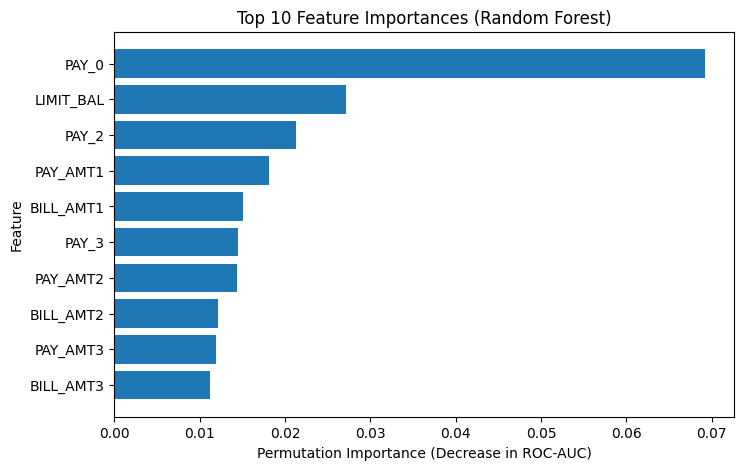

In [48]:
top_n = 10
top_imp = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.xlabel("Permutation Importance (Decrease in ROC-AUC)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importances ({best_model_name})")
plt.show()

### Section Summary

To interpret the best performing nonlinear model, I examined permutation importance for the optimized Random Forest using ROC-AUC as the evaluation metric. The results show that repayment status and payment related variables were the most influential predictors, with `PAY_0` standing out as the single most important feature by a clear margin.

Other highly important variables included `LIMIT_BAL`, `PAY_2`, `PAY_AMT1`, `BILL_AMT1`, `PAY_3`, and several additional bill and payment amount variables. Overall, these findings suggest that recent repayment behavior and financial activity are much more informative for default prediction than simple demographic characteristics, which is consistent with the earlier exploratory analysis.

<hr>

## 12. Results on the test set

- After selecting the best tuned model based on validation performance, I evaluated it on the test set. This final step provides an estimate of how well the model generalizes to unseen data.


### 12.1 Test Performance

In [49]:
best_optimized_model.fit(X_train, y_train)

y_test_pred = best_optimized_model.predict(X_test)
y_test_proba = best_optimized_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "recall": recall_score(y_test, y_test_pred, zero_division=0),
    "f1": f1_score(y_test, y_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_test_proba)
}

test_summary = pd.DataFrame({
    "metric": list(test_metrics.keys()),
    "test_score": list(test_metrics.values())
})

test_summary.round(4)

,metric,test_score
0,accuracy,0.8188
1,precision,0.6824
2,recall,0.3384
3,f1,0.4524
4,roc_auc,0.7792


### 12.2 Confusion Matrix

In [50]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

Confusion matrix [[TN, FP], [FN, TP]]:
[[4464  209]
 [ 878  449]]


### 12.3 Validation Vs. Test

In [51]:
best_model_row_q10 = optimized_summary.loc[
    optimized_summary["model"].str.contains(best_model_name, regex=False)
].iloc[0]

validation_vs_test = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "validation_cv_mean": [
        best_model_row_q10["cv_accuracy_mean"],
        best_model_row_q10["cv_precision_mean"],
        best_model_row_q10["cv_recall_mean"],
        best_model_row_q10["cv_f1_mean"],
        best_model_row_q10["cv_roc_auc_mean"]
    ],
    "validation_cv_std": [
        best_model_row_q10["cv_accuracy_std"],
        best_model_row_q10["cv_precision_std"],
        best_model_row_q10["cv_recall_std"],
        best_model_row_q10["cv_f1_std"],
        best_model_row_q10["cv_roc_auc_std"]
    ],
    "test_score": [
        test_metrics["accuracy"],
        test_metrics["precision"],
        test_metrics["recall"],
        test_metrics["f1"],
        test_metrics["roc_auc"]
    ]
})

validation_vs_test["test_minus_validation"] = (
    validation_vs_test["test_score"] - validation_vs_test["validation_cv_mean"]
)

validation_vs_test.round(4)

,metric,validation_cv_mean,validation_cv_std,test_score,test_minus_validation
0,accuracy,0.8188,0.0014,0.8188,0.0001
1,precision,0.6790,0.0071,0.6824,0.0033
2,recall,0.3426,0.0020,0.3384,-0.0043
3,f1,0.4554,0.0032,0.4524,-0.0030
4,roc_auc,0.7787,0.0027,0.7792,0.0004


### Section Summary

I evaluated the optimized Random Forest model on the held out test set and found that its performance remained very consistent with the cross validation results. On the test set, the model achieved an accuracy of 0.8188, a precision of 0.6824, a recall of 0.3384, an F1-score of 0.4524, and a ROC-AUC of 0.7792.

The validation and test metrics were extremely close across all measures, with only very small differences. This suggests that the model generalized well to unseen data and that the tuning process did not lead to substantial overfitting. 

The confusion matrix further shows that the model correctly identified many non-default cases and was able to detect a meaningful portion of default cases, although recall for the positive class remained moderate. 

Overall, the final test results support the optimized Random Forest as a stable and effective model for this default prediction task.

<hr>

## 13. Summary of results
    
- This section summarizes the main findings of the project by combining model comparison, tuning results, and final test-set evaluation. The goal is to present the most important results in a compact and interpretable format.


In [52]:
summary_results = pd.DataFrame([
    {
        "Stage": "Baseline",
        "Model": "DummyClassifier",
        "ROC AUC": np.nan,
        "F1 Score": f1_score(y_test, y_pred_baseline, zero_division=0),
        "Key Observation": "Always predicts the majority class; accuracy alone is misleading."
    },
    {
        "Stage": "Initial model comparison",
        "Model": "Logistic Regression",
        "ROC AUC": roc_auc_score(y_test, y_prob_logreg),
        "F1 Score": f1_score(y_test, y_pred_logreg, zero_division=0),
        "Key Observation": "Strong linear benchmark with high precision but relatively low recall."
    },
    {
        "Stage": "Initial model comparison",
        "Model": "Decision Tree",
        "ROC AUC": roc_auc_score(y_test, y_prob_dt),
        "F1 Score": f1_score(y_test, y_pred_dt, zero_division=0),
        "Key Observation": "More flexible but weaker overall performance than the best models."
    },
    {
        "Stage": "Initial model comparison",
        "Model": "KNN",
        "ROC AUC": roc_auc_score(y_test, y_prob_knn),
        "F1 Score": f1_score(y_test, y_pred_knn, zero_division=0),
        "Key Observation": "Reasonable non-linear benchmark with moderate overall performance."
    },
    {
        "Stage": "Initial model comparison",
        "Model": "Random Forest",
        "ROC AUC": roc_auc_score(y_test, y_prob_rf),
        "F1 Score": f1_score(y_test, y_pred_rf, zero_division=0),
        "Key Observation": "Best overall untuned model with the strongest balance across metrics."
    },
    {
        "Stage": "Final selected model",
        "Model": best_model_name,
        "ROC AUC": test_metrics["roc_auc"],
        "F1 Score": test_metrics["f1"],
        "Key Observation": "Best tuned model evaluated on the held-out test set."
    }
])

summary_results.round(4)

,Stage,Model,ROC AUC,F1 Score,Key Observation
0,Baseline,DummyClassifier,NaN,0.0000,Always predicts the majority class; accuracy a...
1,Initial model comparison,Logistic Regression,0.7274,0.3475,Strong linear benchmark with high precision bu...
2,Initial model comparison,Decision Tree,0.6013,0.3823,More flexible but weaker overall performance t...
3,Initial model comparison,KNN,0.7044,0.4227,Reasonable non-linear benchmark with moderate ...
4,Initial model comparison,Random Forest,0.7647,0.4745,Best overall untuned model with the strongest ...
5,Final selected model,Random Forest,0.7792,0.4524,Best tuned model evaluated on the held-out tes...


### Section Summary

Across the models I tested, the random forest family performed best overall and provided the strongest balance between ROC-AUC, recall, and F1-score. Logistic regression remained a useful benchmark because it was simple, interpretable, and reasonably competitive, but the non-linear ensemble model captured the data patterns more effectively.

This project also showed that hyperparameter tuning and careful model evaluation matter more than relying on a single metric such as accuracy. Because the dataset is imbalanced, ROC-AUC, recall, and F1-score provided a more informative basis for model comparison and final selection.

<hr>

## 14. Final takeaway

### Reflection:

My biggest takeaway from this project is that a strong machine learning workflow matters more than simply trying more complex models. Careful data splitting, preprocessing, model comparison, hyperparameter tuning, and interpretation were all essential for producing results that were both meaningful and trustworthy.

I also learned that model evaluation needs to match the problem context. In this dataset, class imbalance made accuracy alone a weak metric, so using ROC-AUC, recall, and F1-score led to a more realistic understanding of model quality. Overall, this project reinforced the importance of combining technical modeling with clear interpretation in applied machine learning.

<hr>